# Notebook 05: Model Training
##### Football Match Prediction 
##### Student Name: Vishal Chaudhary
##### Student Number: X23332794

In [1]:
pip install scikit-learn joblib


[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: pip3.12 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


### IMPORT REQUIRED LIBRARIES

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier


import warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.simplefilter(action='ignore', category=FutureWarning)
np.random.seed(42)

pd.set_option('display.max_columns', 200)
pd.set_option('display.max_rows', 200)


### DATA LOADING

In [49]:
# Define paths
DATA_RAW_PATH = Path('/Users/vishalchaudhary/Desktop/Football_Project_Final/DOMAIN_APPLICATIONS_PROJECT/data/raw')
PROCESSED_PATH = Path('/Users/vishalchaudhary/Desktop/Football_Project_Final/DOMAIN_APPLICATIONS_PROJECT/data/processed')
FEATURES_PATH = Path('/Users/vishalchaudhary/Desktop/Football_Project_Final/DOMAIN_APPLICATIONS_PROJECT/data/features')
RESULTS_PATH = Path('/Users/vishalchaudhary/Desktop/Football_Project_Final/DOMAIN_APPLICATIONS_PROJECT/results')
FIGURES_PATH = RESULTS_PATH / 'figures'
TABLES_PATH = RESULTS_PATH / 'tables'
MODEL_PATH = Path('/Users/vishalchaudhary/Desktop/Football_Project_Final/DOMAIN_APPLICATIONS_PROJECT/models')

df = pd.read_csv(FEATURES_PATH/'df_merged_complete_v2.csv')



### FEATURE SELECTION AND DATA PREPARATION

In [4]:

features = [
    'h2h_total_matches', 'h2h_home_wins', 'h2h_draws', 'h2h_away_wins', 'h2h_home_win_pct',
    'h2h_draw_pct', 'h2h_away_win_pct', 'h2h_avg_home_goals', 'h2h_avg_away_goals', 'h2h_avg_total_goals',
    'h2h_btts_pct', 'h2h_over_2_5_pct', 'h2h_last_5_home_wins', 'h2h_last_5_draws', 'h2h_last_5_away_wins',
    'h2h_days_since_last_meeting', 'avg_team_rating', 'total_points', 'total_goals_for', 'total_goals_against',
    'total_clean_sheets', 'away_avg_team_rating', 'away_total_points', 'away_total_goals_for',
    'away_total_goals_against', 'away_total_clean_sheets', 'h2h_rating_diff', 'h2h_points_diff',
    'h2h_injury_diff', 'home_rating_rank_ratio', 'away_rating_rank_ratio', 'home_points_per_game',
    'away_points_per_game', 'h2h_last_5_home_win_pct', 'h2h_last_5_draw_pct', 'h2h_last_5_away_win_pct',
    'h2h_goal_diff', 'home_avg_goals_last_5', 'home_avg_shots_last_5', 'home_avg_points_last_5',
    'away_avg_goals_last_5', 'away_avg_shots_last_5', 'away_avg_points_last_5', 'home_injury_ratio',
    'away_injury_ratio', 'home_team_experience', 'away_team_experience', 'home_formation_defenders',
    'away_formation_defenders', 'home_num_top_players', 'away_num_top_players', 'home_games_played',
    'away_games_played', 'home_draws', 'away_draws', 'home_loses', 'away_loses', 'home_goals_per_game',
    'away_goals_per_game', 'home_goals_conceded_per_game', 'away_goals_conceded_per_game',
    'goal_diff_home', 'goal_diff_away', 'goal_diff_difference', 'home_goals_conceded_L5',
    'away_goals_conceded_L5', 'form_difference', 'home_rolling_shots_on_goal', 'away_rolling_shots_on_goal',
    'shots_on_goal_diff', 'home_rolling_total_shots', 'away_rolling_total_shots', 'total_shots_diff',
    'home_rolling_corners', 'away_rolling_corners', 'corners_diff', 'home_rolling_possession',
    'away_rolling_possession', 'possession_diff', 'home_rolling_passes_accurate', 'away_rolling_passes_accurate',
    'home_rolling_pass_accuracy', 'away_rolling_pass_accuracy', 'pass_accuracy_diff', 'home_shot_efficiency',
    'away_shot_efficiency', 'shot_efficiency_diff', 'home_days_since_last', 'away_days_since_last',
    'days_rest_difference', 'table_proximity', 'is_close_match', 'league_home_advantage', 'league_avg_goals',
    'competitive_balance', 'rank_balance', 'form_balance', 'overall_balance', 'both_defensive',
    'defensive_sum', 'combined_attack', 'low_scoring_likelihood', 'home_draw_tendency', 'away_draw_tendency',
    'combined_draw_tendency', 'dominance_score'
]
target = 'target'

missing = [c for c in features if c not in df.columns]
if missing:
    raise RuntimeError(f"The following features are missing from df: {missing}")

X = df[features].select_dtypes(include=[np.number]).copy()
dropped_from_numeric = set(features) - set(X.columns.tolist())
if dropped_from_numeric:
    print(f"Warning: these provided features were not numeric and will be ignored: {sorted(list(dropped_from_numeric))}")

y = df[target].copy()
if y.isna().any():
    mask = y.notna()
    X = X.loc[mask, :]
    y = y.loc[mask]
    print("Dropped rows with missing target.")

print("X shape:", X.shape, "y distribution:\n", y.value_counts(normalize=True))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train/test sizes:", X_train.shape, X_test.shape)

X shape: (18894, 106) y distribution:
 target
0    0.445274
2    0.313539
1    0.241188
Name: proportion, dtype: float64
Train/test sizes: (15115, 106) (3779, 106)


### Handling Missing Values with Median Imputation

In [5]:
imputer = SimpleImputer(strategy='median')
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

### Feature Scaling with StandardScaler


In [6]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

### Dictionaries TO STORE RESULTS

In [7]:
# Dictionaries to store metrics and predictions for all models
results = {}
cv_results = {}
scale_sensitive = ['LogisticRegression', 'MLPClassifier']

### LogisticRegression

LogisticRegression - ACC=0.6147  PREC=0.6283  REC=0.6147  F1=0.6192

Top 10 Features (mean absolute coefficient):
 home_loses              0.691273
home_games_played       0.665933
away_loses              0.645510
away_games_played       0.401977
home_draws              0.383966
away_draws              0.352256
away_goals_per_game     0.261517
pass_accuracy_diff      0.224708
home_points_per_game    0.213399
home_goals_per_game     0.207667
dtype: float64 



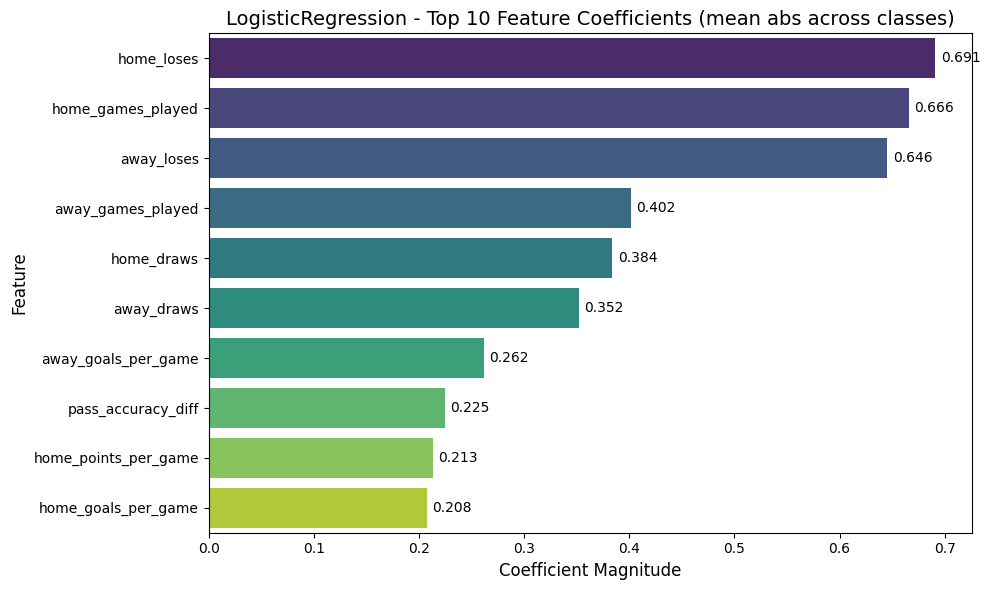

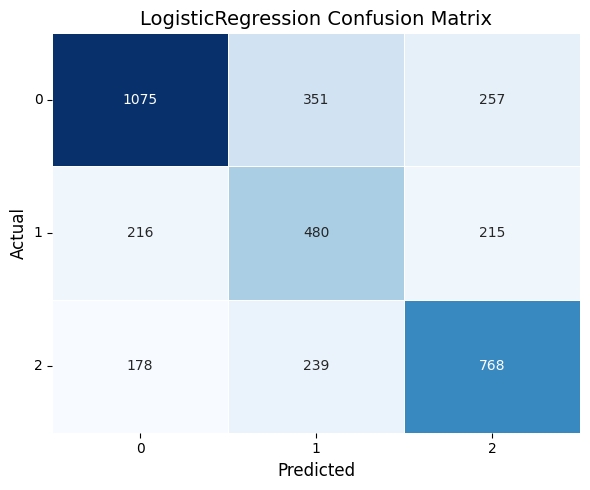

Model saved to: /Users/vishalchaudhary/Desktop/Football_Project_Final/DOMAIN_APPLICATIONS_PROJECT/models/LogisticRegression.joblib
Model saved to: /Users/vishalchaudhary/Desktop/Football_Project_Final/DOMAIN_APPLICATIONS_PROJECT/models/LogisticRegression.pkl


In [58]:
model_name = 'LogisticRegression'
model = LogisticRegression(random_state=42, max_iter=2000, class_weight='balanced')

# Train model
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

# Compute metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

print(f"{model_name} - ACC={acc:.4f}  PREC={prec:.4f}  REC={rec:.4f}  F1={f1:.4f}\n")

# Top 10 coefficients/features
if hasattr(model, 'coef_'):
    coefs = model.coef_
    if coefs.ndim == 2 and coefs.shape[0] > 1:
        mean_abs_coefs = np.mean(np.abs(coefs), axis=0)
    else:
        mean_abs_coefs = np.abs(np.ravel(coefs))
    fi = pd.Series(mean_abs_coefs, index=features).sort_values(ascending=False)
    
    # Print top 10 features
    print("Top 10 Features (mean absolute coefficient):\n", fi.head(10), "\n")
    
    # Bar plot
    plt.figure(figsize=(10,6))
    sns.barplot(x=fi.head(10).values, y=fi.head(10).index, palette='viridis')
    plt.title(f'{model_name} - Top 10 Feature Coefficients (mean abs across classes)', fontsize=14)
    plt.xlabel('Coefficient Magnitude', fontsize=12)
    plt.ylabel('Feature', fontsize=12)
    
    # Annotate bars
    for i, v in enumerate(fi.head(10).values):
        plt.text(v + 0.005, i, f"{v:.3f}", va='center', fontsize=10)
    
    plt.tight_layout()
    plt.savefig(FIGURES_PATH / f'{model_name}_feature_importance.png', dpi=300, bbox_inches='tight') 

    plt.show()

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, linewidths=0.5)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.title(f'{model_name} Confusion Matrix', fontsize=14)
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(FIGURES_PATH / f'{model_name}_confusion_matrix.png', dpi=300, bbox_inches='tight') 
plt.show()

# Save results
results[model_name] = {
    'accuracy': acc,
    'precision': prec,
    'recall': rec,
    'f1_score': f1,
    'predictions': y_pred
}

model_file = MODEL_PATH / f'{model_name}.joblib'
joblib.dump(model, model_file)
print(f"Model saved to: {model_file}")

import pickle

model_file = MODEL_PATH / f"{model_name}.pkl"
with open(model_file, "wb") as f:
    pickle.dump(model, f)

print(f"Model saved to: {model_file}")


### RandomForest

RandomForest - ACC=0.6039  PREC=0.5901  REC=0.6039  F1=0.5791

Top 10 Features:
 goal_diff_difference    0.028133
home_draws              0.027268
away_draws              0.025151
form_balance            0.019900
away_loses              0.019571
away_points_per_game    0.018011
form_difference         0.017916
home_loses              0.017643
h2h_points_diff         0.016345
goal_diff_home          0.015531
dtype: float64 



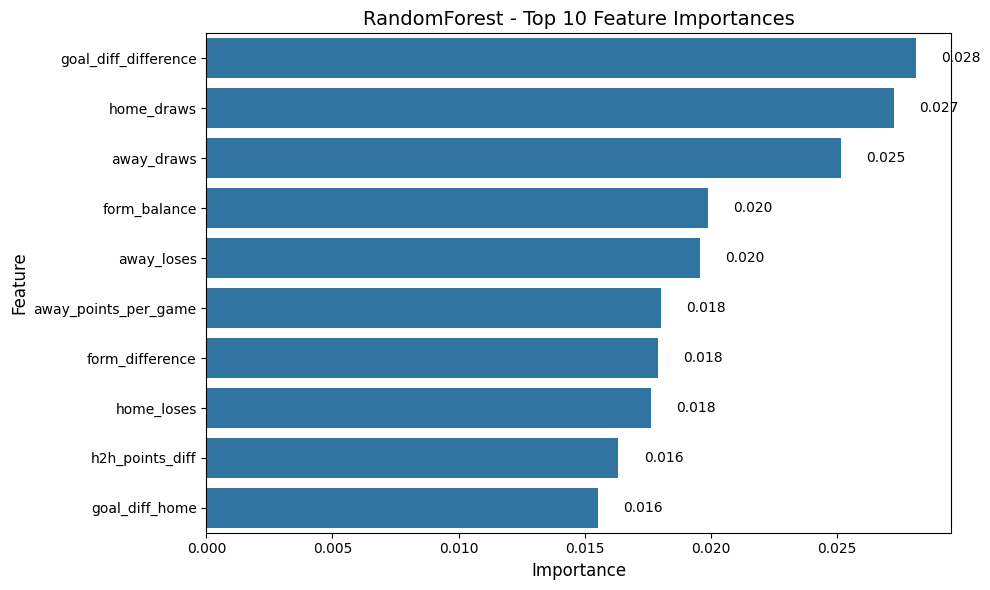

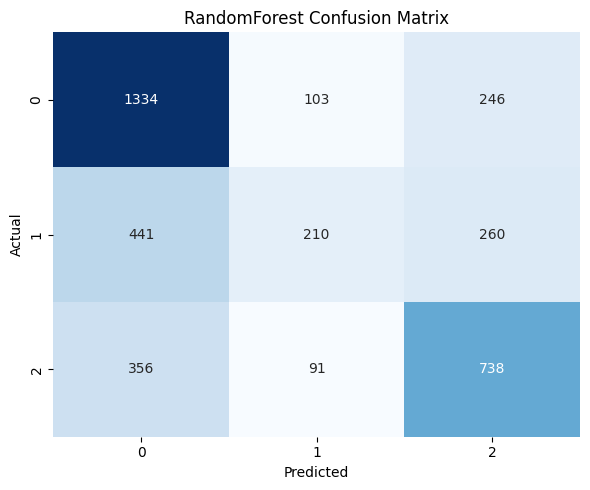

Model saved to: /Users/vishalchaudhary/Desktop/Football_Project_Final/DOMAIN_APPLICATIONS_PROJECT/models/RandomForest.joblib
Model saved to: /Users/vishalchaudhary/Desktop/Football_Project_Final/DOMAIN_APPLICATIONS_PROJECT/models/RandomForest.pkl


In [57]:
model_name = 'RandomForest'
model = RandomForestClassifier(
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

model.fit(X_train_imputed, y_train)
y_pred = model.predict(X_test_imputed)

# Metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

print(f"{model_name} - ACC={acc:.4f}  PREC={prec:.4f}  REC={rec:.4f}  F1={f1:.4f}\n")

#  Feature Importance 
fi = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)

print("Top 10 Features:\n", fi.head(10), "\n")

plt.figure(figsize=(10,6))
sns.barplot(x=fi.head(10).values, y=fi.head(10).index)
plt.title(f'{model_name} - Top 10 Feature Importances', fontsize=14)
plt.xlabel('Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)

for i, v in enumerate(fi.head(10).values):
    plt.text(v + 0.001, i, f"{v:.3f}", va='center')

plt.tight_layout()
plt.savefig(FIGURES_PATH / f'{model_name}_feature_importance.png', dpi=300, bbox_inches='tight') 

plt.show()

#  Confusion Matrix 
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title(f'{model_name} Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig(FIGURES_PATH / f'{model_name}_confusion_matrix.png', dpi=300, bbox_inches='tight') 
plt.show()

# Save results
results[model_name] = {'accuracy': acc,'precision': prec,'recall': rec,'f1_score': f1,'predictions': y_pred}

model_file = MODEL_PATH / f'{model_name}.joblib'
joblib.dump(model, model_file)
print(f"Model saved to: {model_file}")

import pickle

model_file = MODEL_PATH / f"{model_name}.pkl"
with open(model_file, "wb") as f:
    pickle.dump(model, f)

print(f"Model saved to: {model_file}")


### MLPClassifier (NEURAL NETWORK)

MLPClassifier - ACC=0.5496  PREC=0.5450  REC=0.5496  F1=0.5470

Top 10 Features:
 home_loses                    0.121170
away_loses                    0.118444
home_draws                    0.063456
away_draws                    0.063006
home_games_played             0.034692
away_games_played             0.031860
away_goals_per_game           0.030987
away_rolling_pass_accuracy    0.018470
total_shots_diff              0.014581
home_rolling_pass_accuracy    0.014051
dtype: float64 



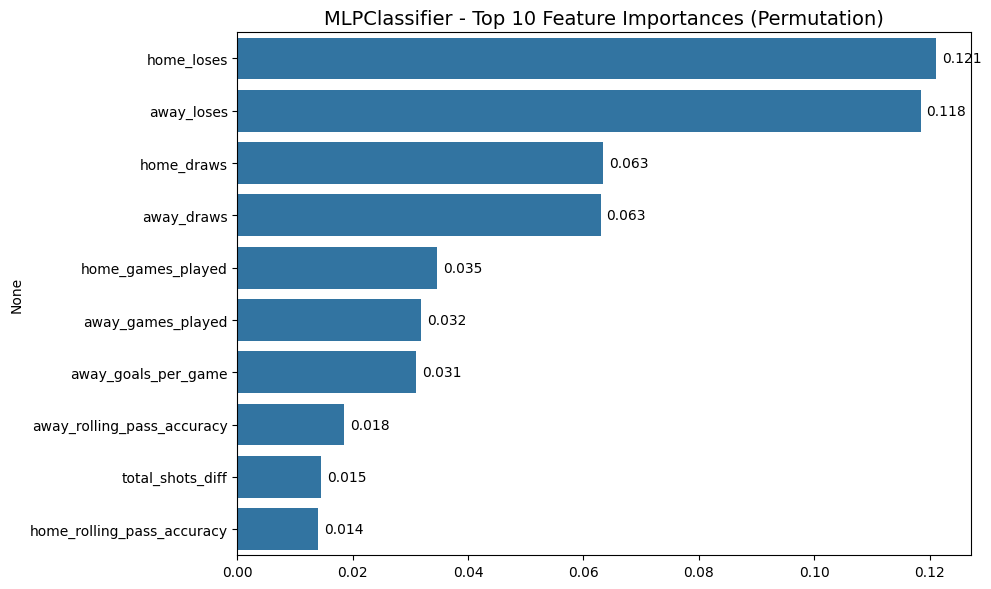

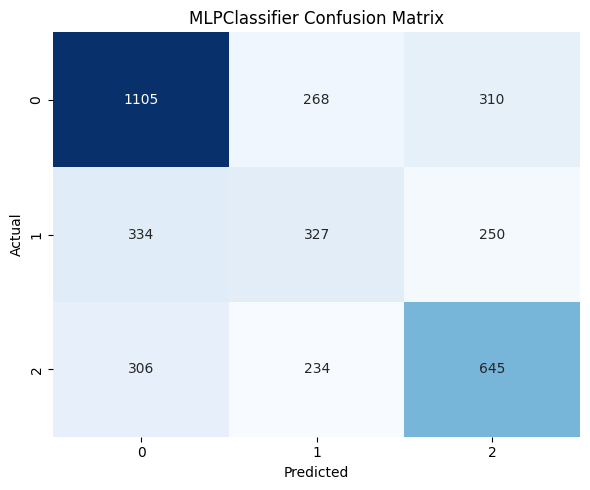

Model saved to: /Users/vishalchaudhary/Desktop/Football_Project_Final/DOMAIN_APPLICATIONS_PROJECT/models/MLPClassifier.joblib
Model saved to: /Users/vishalchaudhary/Desktop/Football_Project_Final/DOMAIN_APPLICATIONS_PROJECT/models/MLPClassifier.pkl


In [56]:
model_name = 'MLPClassifier'
model = MLPClassifier(random_state=42, max_iter=500)

model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

# Metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

print(f"{model_name} - ACC={acc:.4f}  PREC={prec:.4f}  REC={rec:.4f}  F1={f1:.4f}\n")

#  Feature Importance (Permutation Importance) 
from sklearn.inspection import permutation_importance
perm = permutation_importance(model, X_test_scaled, y_test, n_repeats=10, n_jobs=-1)

fi = pd.Series(perm.importances_mean, index=features).sort_values(ascending=False)

print("Top 10 Features:\n", fi.head(10), "\n")

plt.figure(figsize=(10,6))
sns.barplot(x=fi.head(10).values, y=fi.head(10).index)
plt.title(f'{model_name} - Top 10 Feature Importances (Permutation)', fontsize=14)

for i, v in enumerate(fi.head(10).values):
    plt.text(v + 0.001, i, f"{v:.3f}", va='center')

plt.tight_layout()
plt.savefig(FIGURES_PATH / f'{model_name}_feature_importance.png', dpi=300, bbox_inches='tight')  
plt.show()

#  Confusion Matrix 
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title(f'{model_name} Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig(FIGURES_PATH / f'{model_name}_confusion_matrix.png', dpi=300, bbox_inches='tight') 
plt.show()

# Save results
results[model_name] = {'accuracy': acc,'precision': prec,'recall': rec,'f1_score': f1,'predictions': y_pred}

model_file = MODEL_PATH / f'{model_name}.joblib'
joblib.dump(model, model_file)
print(f"Model saved to: {model_file}")

import pickle

model_file = MODEL_PATH / f"{model_name}.pkl"
with open(model_file, "wb") as f:
    pickle.dump(model, f)

print(f"Model saved to: {model_file}")



### XGBClassifier

XGBoost - ACC=0.6115  PREC=0.6011  REC=0.6115  F1=0.6031

Top 10 Features:
 goal_diff_difference    0.106422
home_draws              0.034252
away_draws              0.033792
home_loses              0.031566
away_loses              0.025609
h2h_points_diff         0.019030
both_defensive          0.018975
home_games_played       0.016027
overall_balance         0.011995
total_goals_against     0.011396
dtype: float32 



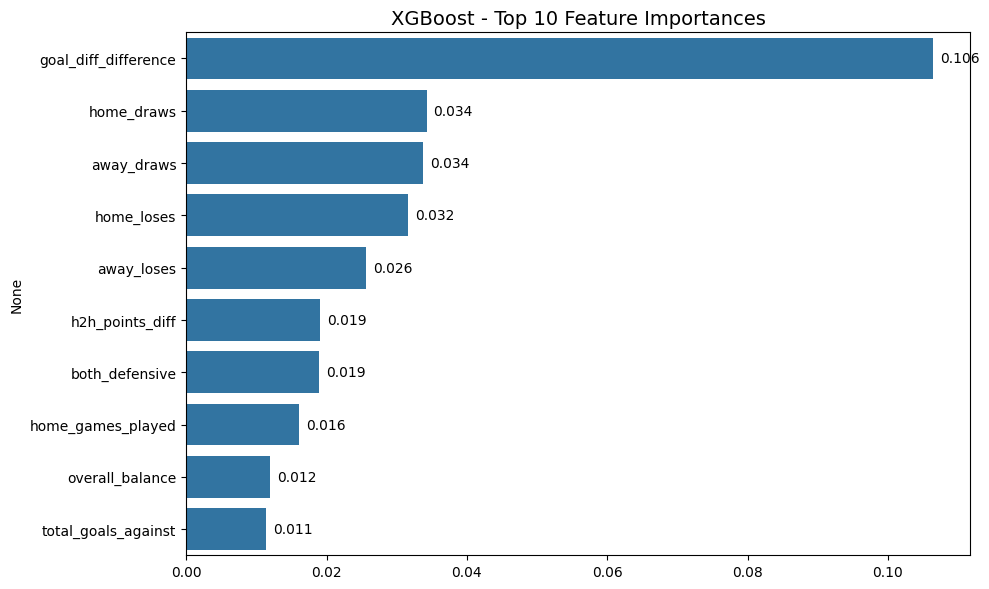

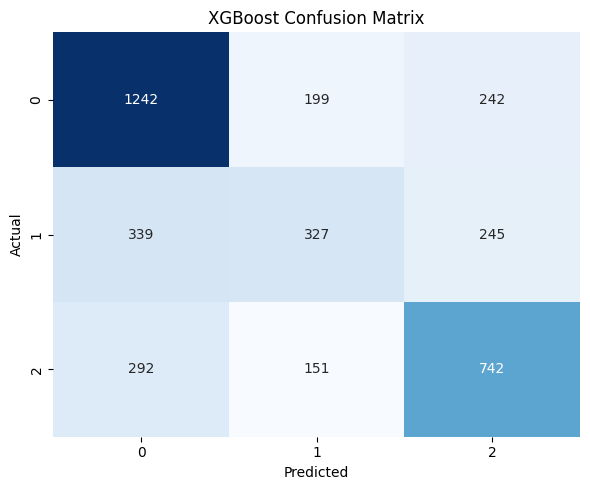

Model saved to: /Users/vishalchaudhary/Desktop/Football_Project_Final/DOMAIN_APPLICATIONS_PROJECT/models/XGBoost.joblib
Model saved to: /Users/vishalchaudhary/Desktop/Football_Project_Final/DOMAIN_APPLICATIONS_PROJECT/models/XGBoost.pkl


In [54]:
model_name = 'XGBoost'
model = XGBClassifier(
    random_state=42,
    eval_metric='mlogloss',
    use_label_encoder=False,
    n_jobs=4
)

model.fit(X_train_imputed, y_train)
y_pred = model.predict(X_test_imputed)

# Metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

print(f"{model_name} - ACC={acc:.4f}  PREC={prec:.4f}  REC={rec:.4f}  F1={f1:.4f}\n")

#  Feature Importance 
fi = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)

print("Top 10 Features:\n", fi.head(10), "\n")

plt.figure(figsize=(10,6))
sns.barplot(x=fi.head(10).values, y=fi.head(10).index)
plt.title(f'{model_name} - Top 10 Feature Importances', fontsize=14)

for i, v in enumerate(fi.head(10).values):
    plt.text(v + 0.001, i, f"{v:.3f}", va='center')

plt.tight_layout()
plt.savefig(FIGURES_PATH / f'{model_name}_feature_importance.png', dpi=300, bbox_inches='tight')  
plt.show()

#  Confusion Matrix 
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title(f'{model_name} Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig(FIGURES_PATH / f'{model_name}_confusion_matrix.png', dpi=300, bbox_inches='tight') 
plt.show()

# Save results
results[model_name] = {'accuracy': acc,'precision': prec,'recall': rec,'f1_score': f1,'predictions': y_pred}

model_file = MODEL_PATH / f'{model_name}.joblib'
joblib.dump(model, model_file)
print(f"Model saved to: {model_file}")
import pickle

model_file = MODEL_PATH / f"{model_name}.pkl"
with open(model_file, "wb") as f:
    pickle.dump(model, f)

print(f"Model saved to: {model_file}")



### LIGHTGBM

LightGBM - ACC=0.6272  PREC=0.6177  REC=0.6272  F1=0.6187

Top 10 Features:
 away_loses              353
home_loses              352
away_draws              328
home_draws              326
home_shot_efficiency    228
away_shot_efficiency    206
total_shots_diff        178
shot_efficiency_diff    172
goal_diff_difference    166
home_days_since_last    146
dtype: int32 



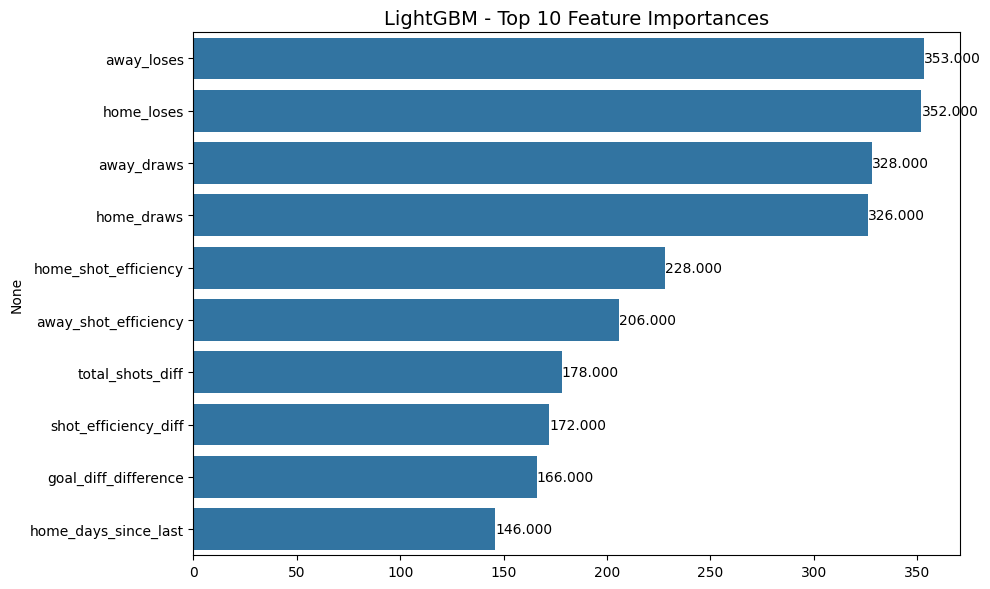

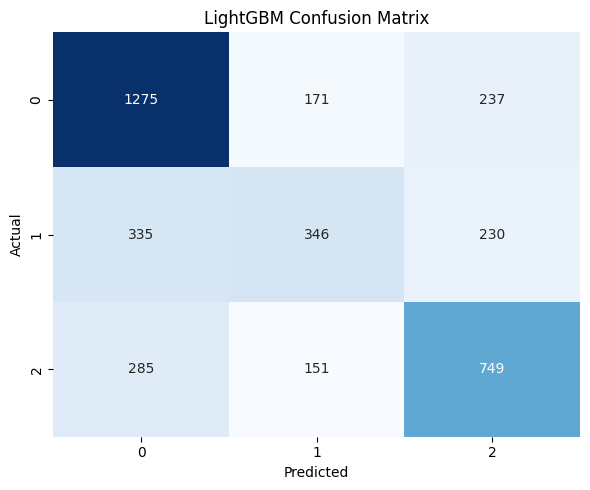

Model saved to: /Users/vishalchaudhary/Desktop/Football_Project_Final/DOMAIN_APPLICATIONS_PROJECT/models/LightGBM.joblib
Model saved to: /Users/vishalchaudhary/Desktop/Football_Project_Final/DOMAIN_APPLICATIONS_PROJECT/models/LightGBM.pkl


In [55]:
model_name = 'LightGBM'
model = LGBMClassifier(
    random_state=42,
    n_jobs=4,
    verbose=-1
)

model.fit(X_train_imputed, y_train)
y_pred = model.predict(X_test_imputed)

# Metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

print(f"{model_name} - ACC={acc:.4f}  PREC={prec:.4f}  REC={rec:.4f}  F1={f1:.4f}\n")

#  Feature Importance 
fi = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)

print("Top 10 Features:\n", fi.head(10), "\n")

plt.figure(figsize=(10,6))
sns.barplot(x=fi.head(10).values, y=fi.head(10).index)
plt.title(f'{model_name} - Top 10 Feature Importances', fontsize=14)

for i, v in enumerate(fi.head(10).values):
    plt.text(v + 0.001, i, f"{v:.3f}", va='center')

plt.tight_layout()
plt.savefig(FIGURES_PATH / f'{model_name}_feature_importance.png', dpi=300, bbox_inches='tight')  
plt.show()

#  Confusion Matrix 
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title(f'{model_name} Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig(FIGURES_PATH / f'{model_name}_confusion_matrix.png', dpi=300, bbox_inches='tight') 
plt.show()

# Save results
results[model_name] = {'accuracy': acc,'precision': prec,'recall': rec,'f1_score': f1,'predictions': y_pred}

model_file = MODEL_PATH / f'{model_name}.joblib'
joblib.dump(model, model_file)
print(f"Model saved to: {model_file}")

import pickle

model_file = MODEL_PATH / f"{model_name}.pkl"
with open(model_file, "wb") as f:
    pickle.dump(model, f)

print(f"Model saved to: {model_file}")


### CROSS VALIDATION

In [13]:
cv_results = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scale_sensitive = ['LogisticRegression', 'MLPClassifier']

models = {
    'LogisticRegression': LogisticRegression(random_state=42, max_iter=2000, class_weight='balanced'),
    'RandomForest': RandomForestClassifier(random_state=42, n_jobs=-1, class_weight='balanced'),
    'MLPClassifier': MLPClassifier(random_state=42, max_iter=500),
}

try:
    models['XGBoost'] = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss', n_jobs=4)
except Exception as e:
    print("XGBoost not available:", e)

try:
    models['LightGBM'] = LGBMClassifier(random_state=42, n_jobs=4, verbose=-1)
except Exception as e:
    print("LightGBM not available:", e)

for name, model in models.items():
    print(f"Cross-validating {name}...")

    try:
        if name in scale_sensitive:
            scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='accuracy', n_jobs=-1)
        else:
            scores = cross_val_score(model, X_train_imputed, y_train, cv=cv, scoring='accuracy', n_jobs=-1)

        cv_results[name] = {
            'mean': scores.mean(),
            'std': scores.std(),
            'scores': scores.tolist()
        }

        print(f"  CV Accuracy: {scores.mean():.4f} (+/- {scores.std():.4f})\n")

    except Exception as e:
        print(f"  ERROR in {name}: {e}\n")


Cross-validating LogisticRegression...
  CV Accuracy: 0.6067 (+/- 0.0058)

Cross-validating RandomForest...
  CV Accuracy: 0.5942 (+/- 0.0072)

Cross-validating MLPClassifier...
  CV Accuracy: 0.5251 (+/- 0.0103)

Cross-validating XGBoost...
  CV Accuracy: 0.6037 (+/- 0.0075)

Cross-validating LightGBM...
  CV Accuracy: 0.6177 (+/- 0.0091)



In [14]:
print("RESULTS keys:", results.keys())
print("CV_RESULTS keys:", cv_results.keys())

RESULTS keys: dict_keys(['LogisticRegression', 'RandomForest', 'MLPClassifier', 'XGBoost', 'LightGBM'])
CV_RESULTS keys: dict_keys(['LogisticRegression', 'RandomForest', 'MLPClassifier', 'XGBoost', 'LightGBM'])


### MODEL COMPARISON SUMMARY

MODEL COMPARISON SUMMARY

             Model  Test Accuracy  CV Accuracy   CV Std  Precision   Recall  F1-Score
          LightGBM       0.627150     0.617665 0.009060   0.617659 0.627150  0.618691
LogisticRegression       0.614713     0.606748 0.005777   0.628264 0.614713  0.619222
           XGBoost       0.611537     0.603705 0.007538   0.601077 0.611537  0.603149
      RandomForest       0.603863     0.594244 0.007201   0.590127 0.603863  0.579081
     MLPClassifier       0.549616     0.525108 0.010261   0.544953 0.549616  0.546977

Best Model: LightGBM
Best Accuracy: 0.6272


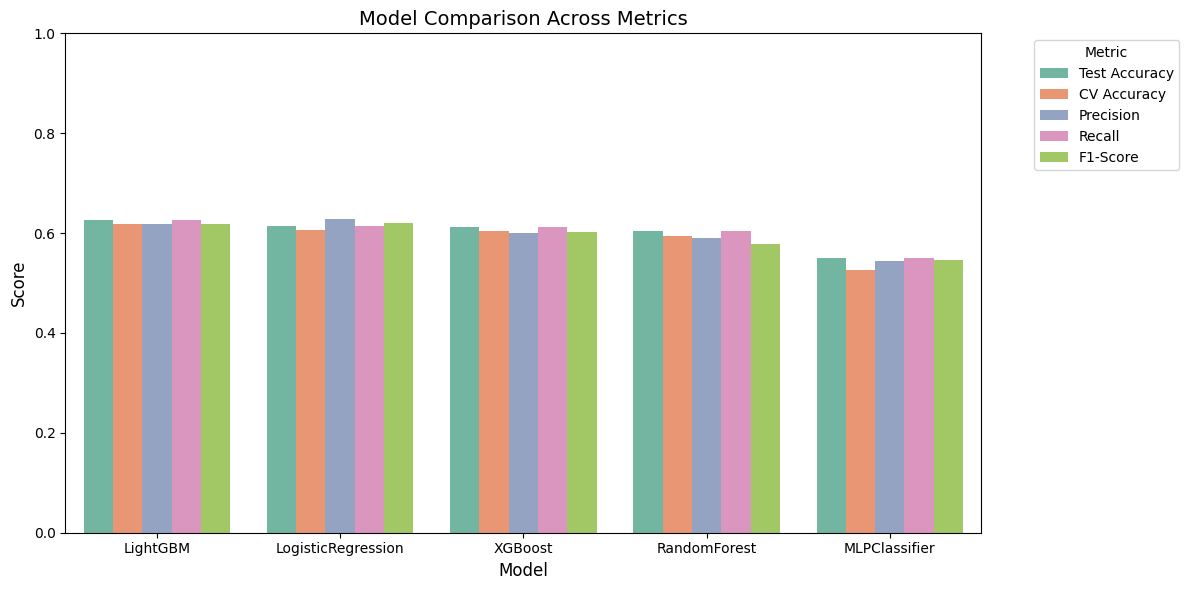

Model comparison table saved to: /Users/vishalchaudhary/Desktop/Football_Project_Final/DOMAIN_APPLICATIONS_PROJECT/results/tables/model_comparison.csv


In [50]:

comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Test Accuracy': [results[m]['accuracy'] for m in results.keys()],
    'CV Accuracy': [cv_results[m]['mean'] for m in results.keys()],
    'CV Std': [cv_results[m]['std'] for m in results.keys()],
    'Precision': [results[m]['precision'] for m in results.keys()],
    'Recall': [results[m]['recall'] for m in results.keys()],
    'F1-Score': [results[m]['f1_score'] for m in results.keys()]
})

comparison_df = comparison_df.sort_values('Test Accuracy', ascending=False).reset_index(drop=True)

print("MODEL COMPARISON SUMMARY\n")
print(comparison_df.to_string(index=False))
print()

best_model_name = comparison_df.iloc[0]['Model']
print(f"Best Model: {best_model_name}")
print(f"Best Accuracy: {comparison_df.iloc[0]['Test Accuracy']:.4f}")


plt.figure(figsize=(12,6))
comparison_df_melted = pd.melt(
    comparison_df, 
    id_vars=['Model'], 
    value_vars=['Test Accuracy', 'CV Accuracy', 'Precision', 'Recall', 'F1-Score']
)

sns.barplot(
    x='Model', 
    y='value', 
    hue='variable', 
    data=comparison_df_melted, 
    dodge=True,  # separates bars per metric
    palette='Set2'
)

plt.title('Model Comparison Across Metrics', fontsize=14)
plt.ylabel('Score', fontsize=12)
plt.xlabel('Model', fontsize=12)
plt.ylim(0, 1)  # optional, ensures scale fits all metrics
plt.xticks(rotation=0)
plt.legend(title='Metric', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(FIGURES_PATH / 'model_comparision.png', dpi=300, bbox_inches='tight') 
plt.show()

comparison_file_csv = TABLES_PATH / 'model_comparison.csv'
comparison_df.to_csv(comparison_file_csv, index=False)
print(f"Model comparison table saved to: {comparison_file_csv}")

### CLASSIFICATION REPORTS FOR ALL MODELS

In [ ]:
# CLASSIFICATION REPORTS FOR ALL MODELS
print("CLASSIFICATION REPORTS\n")

for name in results.keys():
    print(f"{name}:")
    y_pred = results[name]['predictions']
    print(classification_report(
        y_test, y_pred, target_names=['Home Win', 'Draw', 'Away Win'], zero_division=0
    ))
    print()


CLASSIFICATION REPORTS

LogisticRegression:
              precision    recall  f1-score   support

    Home Win       0.73      0.64      0.68      1683
        Draw       0.45      0.53      0.48       911
    Away Win       0.62      0.65      0.63      1185

    accuracy                           0.61      3779
   macro avg       0.60      0.60      0.60      3779
weighted avg       0.63      0.61      0.62      3779


RandomForest:
              precision    recall  f1-score   support

    Home Win       0.63      0.79      0.70      1683
        Draw       0.52      0.23      0.32       911
    Away Win       0.59      0.62      0.61      1185

    accuracy                           0.60      3779
   macro avg       0.58      0.55      0.54      3779
weighted avg       0.59      0.60      0.58      3779


MLPClassifier:
              precision    recall  f1-score   support

    Home Win       0.63      0.66      0.64      1683
        Draw       0.39      0.36      0.38       911


# HYPERTUNING 

In [17]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler
import numpy as np

# Define parameter grids
param_grids = {
    'LogisticRegression': {
        'C': [0.01, 0.1, 1, 10],
        'solver': ['lbfgs', 'liblinear'],
        'max_iter': [2000],
        'class_weight': ['balanced']
    },
    'RandomForest': {
        'n_estimators': [100, 300, 500],
        'max_depth': [None, 5, 10],
        'min_samples_split': [2, 5],
        'class_weight': ['balanced']
    },
    'MLPClassifier': {
        'hidden_layer_sizes': [(50,), (100,), (100,50)],
        'activation': ['relu', 'tanh'],
        'alpha': [0.0001, 0.001],
        'max_iter': [500]
    },
    'XGBoost': {
        'n_estimators': [100, 300, 500],
        'max_depth': [3, 5, 7],
        'learning_rate': [0.01, 0.1, 0.2],
        'subsample': [0.8, 1]
    },
    'LightGBM': {
        'n_estimators': [100, 300, 500],
        'max_depth': [-1, 5, 10],
        'learning_rate': [0.01, 0.1, 0.2],
        'num_leaves': [31, 50, 100]
    }
}

# Models
models = {
    'LogisticRegression': LogisticRegression(random_state=42),
    'RandomForest': RandomForestClassifier(random_state=42, n_jobs=-1),
    'MLPClassifier': MLPClassifier(random_state=42),
}

try:
    models['XGBoost'] = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss', n_jobs=-1)
except:
    print("XGBoost not available")

try:
    models['LightGBM'] = LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1)
except:
    print("LightGBM not available")

best_models = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Hyperparameter tuning loop
for name, model in models.items():
    print(f"Tuning {name}...")
    X_train_input = X_train_scaled if name in ['LogisticRegression', 'MLPClassifier'] else X_train_imputed
    grid = GridSearchCV(model, param_grids[name], cv=cv, scoring='accuracy', n_jobs=-1, verbose=1)
    grid.fit(X_train_input, y_train)
    best_models[name] = grid.best_estimator_
    print(f"Best params for {name}: {grid.best_params_}\n")


Tuning LogisticRegression...
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best params for LogisticRegression: {'C': 0.1, 'class_weight': 'balanced', 'max_iter': 2000, 'solver': 'liblinear'}

Tuning RandomForest...
Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best params for RandomForest: {'class_weight': 'balanced', 'max_depth': None, 'min_samples_split': 5, 'n_estimators': 300}

Tuning MLPClassifier...
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best params for MLPClassifier: {'activation': 'relu', 'alpha': 0.001, 'hidden_layer_sizes': (50,), 'max_iter': 500}

Tuning XGBoost...
Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best params for XGBoost: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}

Tuning LightGBM...
Fitting 5 folds for each of 81 candidates, totalling 405 fits
Best params for LightGBM: {'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 500, 'num_leaves': 31}



In [ ]:
# Save each tuned model
for name, model in best_models.items():
    model_file = MODEL_PATH / f'{name}_tuned.joblib'
    joblib.dump(model, model_file)
    print(f"{name} saved successfully to: {model_file}")

LogisticRegression saved successfully to: /Users/vishalchaudhary/Desktop/Football_Project_Final/DOMAIN_APPLICATIONS_PROJECT/models/LogisticRegression_tuned.joblib
RandomForest saved successfully to: /Users/vishalchaudhary/Desktop/Football_Project_Final/DOMAIN_APPLICATIONS_PROJECT/models/RandomForest_tuned.joblib
MLPClassifier saved successfully to: /Users/vishalchaudhary/Desktop/Football_Project_Final/DOMAIN_APPLICATIONS_PROJECT/models/MLPClassifier_tuned.joblib
XGBoost saved successfully to: /Users/vishalchaudhary/Desktop/Football_Project_Final/DOMAIN_APPLICATIONS_PROJECT/models/XGBoost_tuned.joblib
LightGBM saved successfully to: /Users/vishalchaudhary/Desktop/Football_Project_Final/DOMAIN_APPLICATIONS_PROJECT/models/LightGBM_tuned.joblib


In [52]:
import pickle

# Save each tuned model as .pkl
for name, model in best_models.items():
    model_file = MODEL_PATH / f"{name}_tuned.pkl"
    with open(model_file, "wb") as f:
        pickle.dump(model, f)

    print(f"{name} saved successfully to: {model_file}")


LogisticRegression saved successfully to: /Users/vishalchaudhary/Desktop/Football_Project_Final/DOMAIN_APPLICATIONS_PROJECT/models/LogisticRegression_tuned.pkl
RandomForest saved successfully to: /Users/vishalchaudhary/Desktop/Football_Project_Final/DOMAIN_APPLICATIONS_PROJECT/models/RandomForest_tuned.pkl
MLPClassifier saved successfully to: /Users/vishalchaudhary/Desktop/Football_Project_Final/DOMAIN_APPLICATIONS_PROJECT/models/MLPClassifier_tuned.pkl
XGBoost saved successfully to: /Users/vishalchaudhary/Desktop/Football_Project_Final/DOMAIN_APPLICATIONS_PROJECT/models/XGBoost_tuned.pkl
LightGBM saved successfully to: /Users/vishalchaudhary/Desktop/Football_Project_Final/DOMAIN_APPLICATIONS_PROJECT/models/LightGBM_tuned.pkl


In [ ]:
import pickle

with open(MODEL_PATH / "XGBoost_tuned.pkl", "rb") as f:
    xgb_tuned = pickle.load(f)

### Hyper-Tuned Model Summary, Metrics, and Top Features

Evaluating LogisticRegression...
LogisticRegression - ACC=0.6256  PREC=0.6221  REC=0.6256  F1=0.6232

Top 10 Features:
 away_loses              0.930698
home_loses              0.927912
home_games_played       0.789948
home_draws              0.533801
away_draws              0.507274
away_games_played       0.493304
away_goals_per_game     0.355764
home_goals_per_game     0.334934
home_points_per_game    0.324794
total_points            0.276165
dtype: float64 



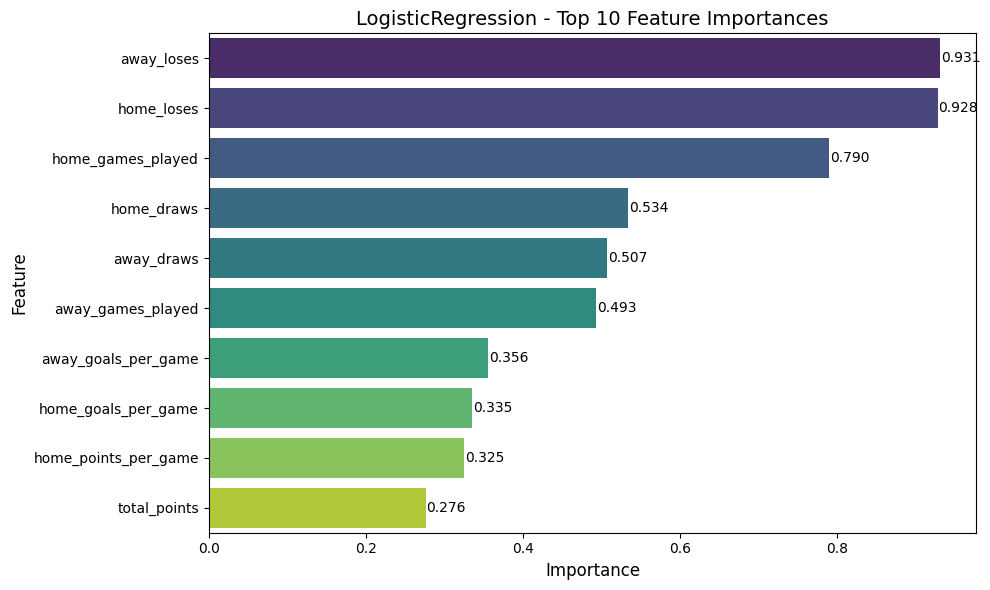

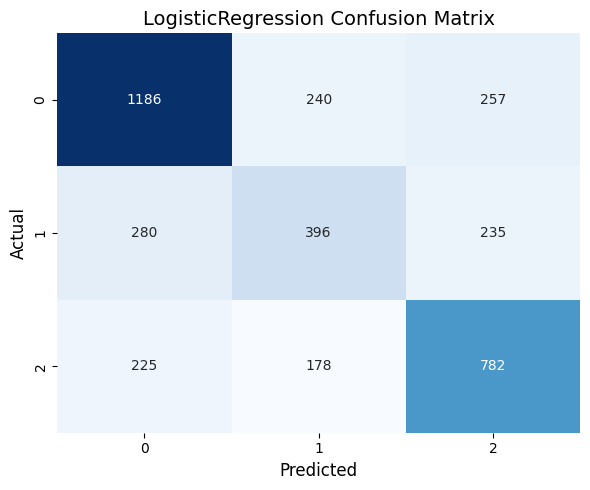

Evaluating RandomForest...
RandomForest - ACC=0.6036  PREC=0.5870  REC=0.6036  F1=0.5811

Top 10 Features:
 home_draws              0.029040
goal_diff_difference    0.028571
away_draws              0.026913
away_loses              0.022196
form_balance            0.019603
h2h_points_diff         0.019114
away_points_per_game    0.018606
form_difference         0.018418
home_loses              0.018105
goal_diff_home          0.015789
dtype: float64 



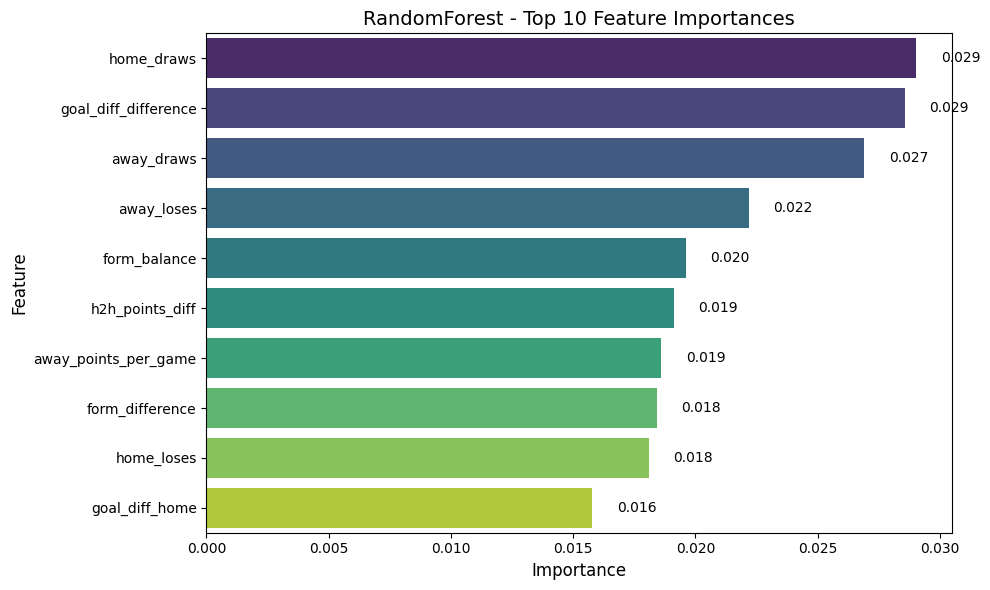

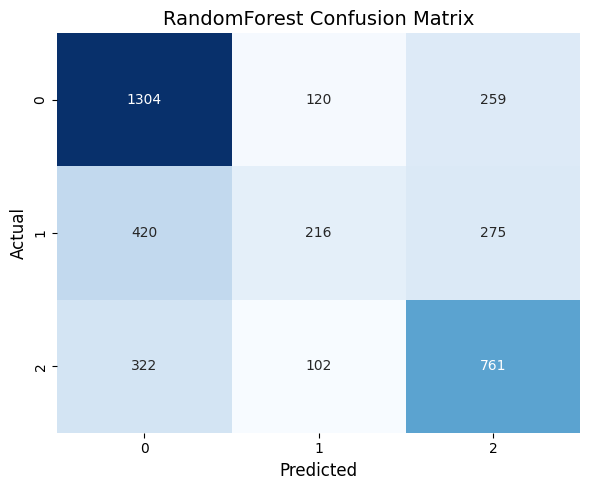

Evaluating MLPClassifier...
MLPClassifier - ACC=0.5740  PREC=0.5658  REC=0.5740  F1=0.5680

Top 10 Features:
 home_loses                      0.143424
away_loses                      0.134559
home_draws                      0.075232
away_draws                      0.070707
home_games_played               0.066949
away_points_per_game            0.051892
away_games_played               0.043821
home_goals_per_game             0.022599
away_goals_per_game             0.021461
home_goals_conceded_per_game    0.020773
dtype: float64 



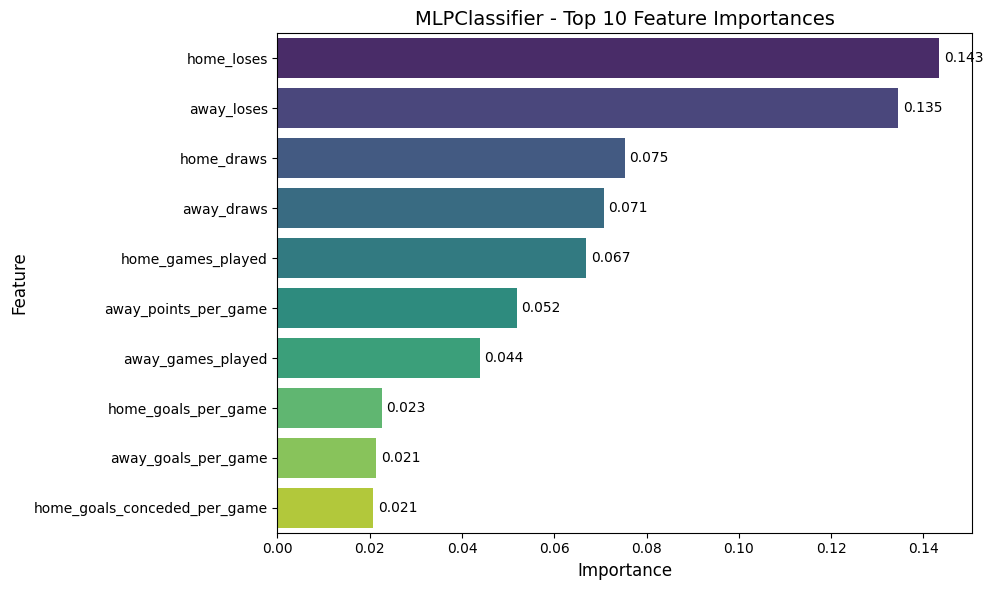

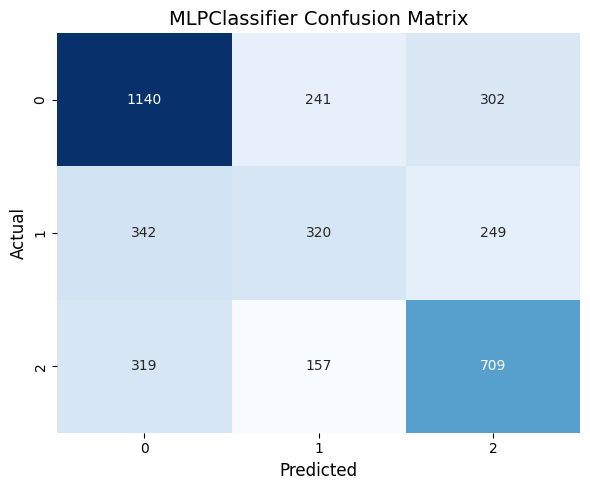

Evaluating XGBoost...
XGBoost - ACC=0.6377  PREC=0.6305  REC=0.6377  F1=0.6286

Top 10 Features:
 goal_diff_difference    0.172442
combined_attack         0.032823
h2h_points_diff         0.029820
home_loses              0.027859
home_draws              0.027799
away_draws              0.027044
away_loses              0.024981
total_goals_for         0.023529
total_goals_against     0.022375
overall_balance         0.022139
dtype: float32 



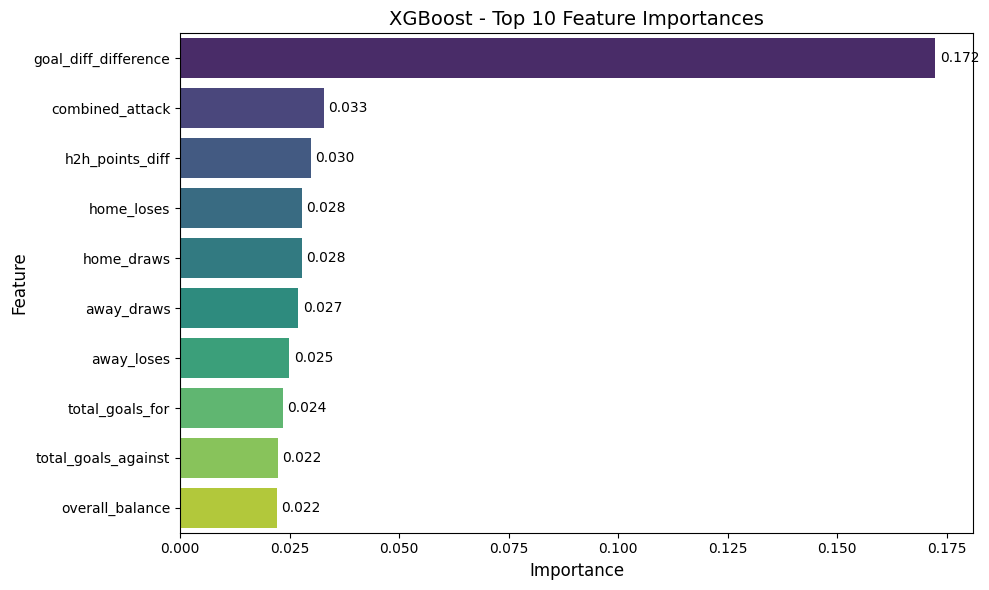

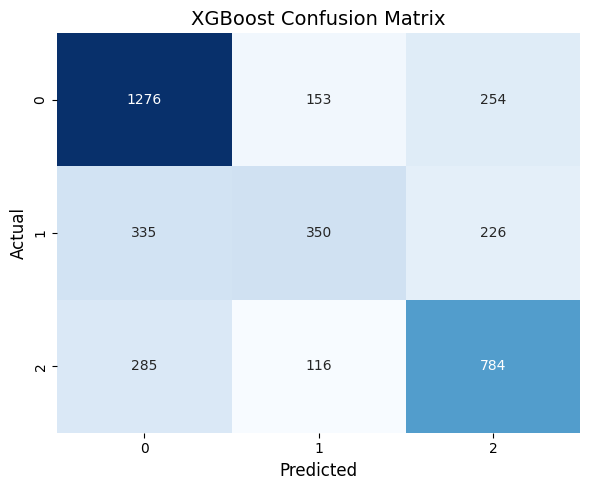

Evaluating LightGBM...
LightGBM - ACC=0.6322  PREC=0.6239  REC=0.6322  F1=0.6222

Top 10 Features:
 away_loses              3584
home_loses              3545
away_draws              3347
goal_diff_difference    2864
home_draws              2788
home_games_played       1317
away_shot_efficiency    1141
defensive_sum           1051
total_goals_against      866
days_rest_difference     785
dtype: int32 



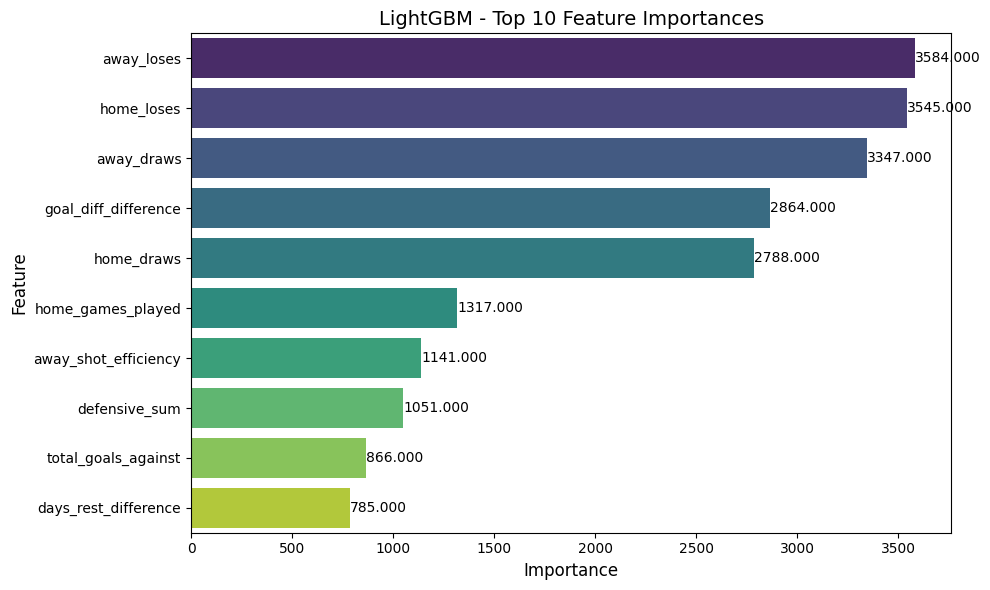

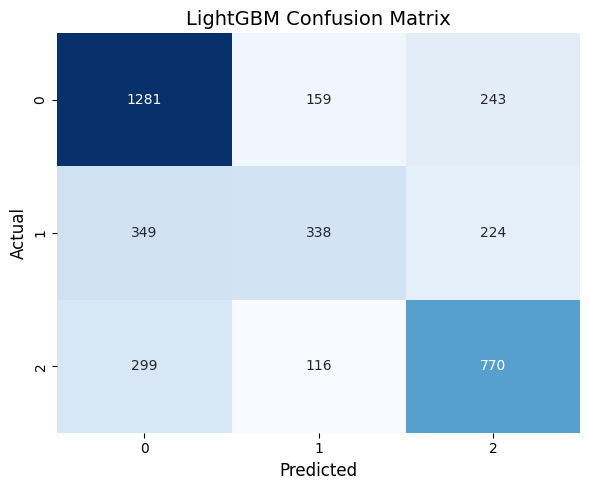

In [47]:
from sklearn.inspection import permutation_importance

results_tuned = {}

for name, model in best_models.items():
    print(f"Evaluating {name}...")
    
    X_test_input = X_test_scaled if name in ['LogisticRegression', 'MLPClassifier'] else X_test_imputed
    y_pred = model.predict(X_test_input)
    
    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    
    print(f"{name} - ACC={acc:.4f}  PREC={prec:.4f}  REC={rec:.4f}  F1={f1:.4f}\n")
    
    # Feature importance
    if hasattr(model, 'coef_'):
        coefs = model.coef_
        if coefs.ndim == 2 and coefs.shape[0] > 1:
            mean_abs_coefs = np.mean(np.abs(coefs), axis=0)
        else:
            mean_abs_coefs = np.abs(np.ravel(coefs))
        fi = pd.Series(mean_abs_coefs, index=features).sort_values(ascending=False)
    elif hasattr(model, 'feature_importances_'):
        fi = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)
    else:  # Permutation importance
        perm = permutation_importance(model, X_test_input, y_test, n_repeats=10, n_jobs=-1)
        fi = pd.Series(perm.importances_mean, index=features).sort_values(ascending=False)
    
    print("Top 10 Features:\n", fi.head(10), "\n")
    
    # Bar plot of top features
    plt.figure(figsize=(10,6))
    sns.barplot(x=fi.head(10).values, y=fi.head(10).index, palette='viridis')
    plt.title(f'{name} - Top 10 Feature Importances', fontsize=14)
    plt.xlabel('Importance', fontsize=12)
    plt.ylabel('Feature', fontsize=12)
    for i, v in enumerate(fi.head(10).values):
        plt.text(v + 0.001, i, f"{v:.3f}", va='center')
    plt.tight_layout()
    # Save feature importance plot
    plt.savefig(FIGURES_PATH / f'{name}_tuned_feature_importance.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'{name} Confusion Matrix', fontsize=14)
    plt.xlabel('Predicted', fontsize=12)
    plt.ylabel('Actual', fontsize=12)
    plt.tight_layout()
    # Save confusion matrix plot
    plt.savefig(FIGURES_PATH / f'{name}_tuned_confusion_matrix.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Save results
    results_tuned[name] = {
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1_score': f1,
        'predictions': y_pred
    }


### Hyper-Tuned Model Comparison Plot

HYPER-TUNED MODEL COMPARISON

             Model  Accuracy  Precision   Recall  F1-Score
           XGBoost  0.637735   0.630526 0.637735  0.628623
          LightGBM  0.632178   0.623864 0.632178  0.622206
LogisticRegression  0.625562   0.622109 0.625562  0.623221
      RandomForest  0.603599   0.586998 0.603599  0.581118
     MLPClassifier  0.573961   0.565791 0.573961  0.568022


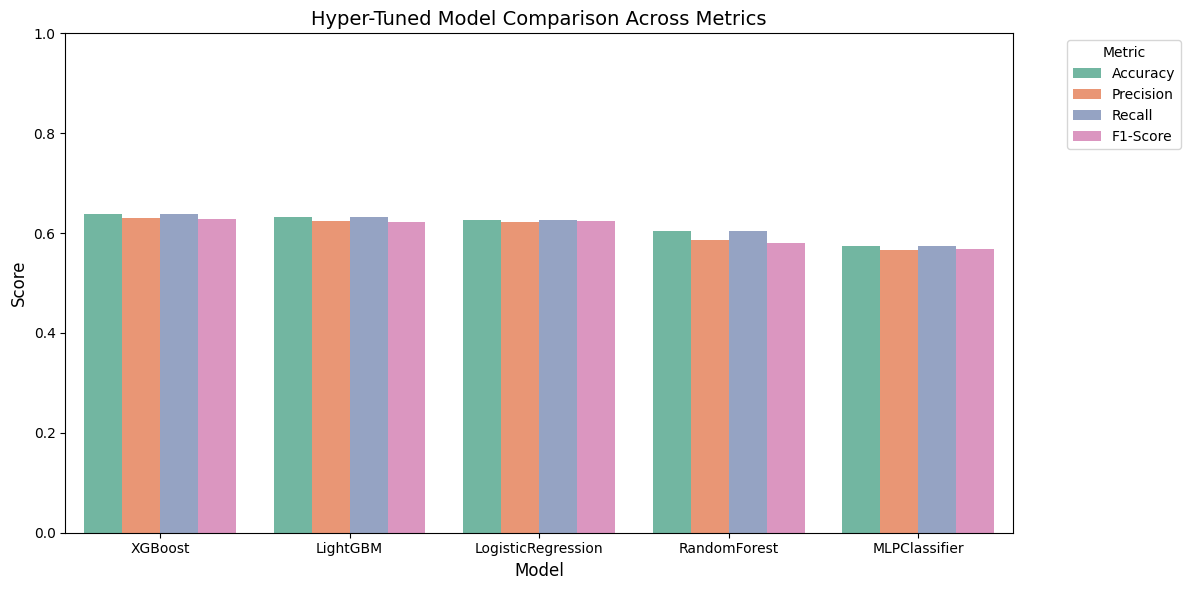

Best Hyper-Tuned Model: XGBoost
Best Accuracy: 0.6377
Model comparison table saved to: /Users/vishalchaudhary/Desktop/Football_Project_Final/DOMAIN_APPLICATIONS_PROJECT/results/tables/model_comparison_tuned.csv


In [51]:
comparison_df_tuned = pd.DataFrame({
    'Model': list(results_tuned.keys()),
    'Accuracy': [results_tuned[m]['accuracy'] for m in results_tuned.keys()],
    'Precision': [results_tuned[m]['precision'] for m in results_tuned.keys()],
    'Recall': [results_tuned[m]['recall'] for m in results_tuned.keys()],
    'F1-Score': [results_tuned[m]['f1_score'] for m in results_tuned.keys()]
}).sort_values('Accuracy', ascending=False).reset_index(drop=True)

print("HYPER-TUNED MODEL COMPARISON\n")
print(comparison_df_tuned.to_string(index=False))

plt.figure(figsize=(12,6))
comparison_df_melted = pd.melt(
    comparison_df_tuned, 
    id_vars=['Model'], 
    value_vars=['Accuracy', 'Precision', 'Recall', 'F1-Score']
)

sns.barplot(
    x='Model', 
    y='value', 
    hue='variable', 
    data=comparison_df_melted, 
    dodge=True,  
    palette='Set2'
)
plt.title('Hyper-Tuned Model Comparison Across Metrics', fontsize=14)
plt.ylabel('Score', fontsize=12)
plt.xlabel('Model', fontsize=12)
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title='Metric', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(FIGURES_PATH / 'model_comparision_tuned.png', dpi=300, bbox_inches='tight')
plt.show()

best_model_name = comparison_df_tuned.iloc[0]['Model']
print(f"Best Hyper-Tuned Model: {best_model_name}")
print(f"Best Accuracy: {comparison_df_tuned.iloc[0]['Accuracy']:.4f}")

comparison_file_csv = TABLES_PATH / 'model_comparison_tuned.csv'
comparison_df.to_csv(comparison_file_csv, index=False)
print(f"Model comparison table saved to: {comparison_file_csv}")

### Classification Reports for Hyper-Tuned Models

In [20]:
print("CLASSIFICATION REPORTS FOR HYPER-TUNED MODELS\n")

target_names = ['Home Win', 'Draw', 'Away Win']  # replace with your actual classes
for name in results_tuned.keys():
    print(f"{name}:")
    y_pred = results_tuned[name]['predictions']
    print(classification_report(y_test, y_pred, target_names=target_names, zero_division=0))
    print()


CLASSIFICATION REPORTS FOR HYPER-TUNED MODELS

LogisticRegression:
              precision    recall  f1-score   support

    Home Win       0.70      0.70      0.70      1683
        Draw       0.49      0.43      0.46       911
    Away Win       0.61      0.66      0.64      1185

    accuracy                           0.63      3779
   macro avg       0.60      0.60      0.60      3779
weighted avg       0.62      0.63      0.62      3779


RandomForest:
              precision    recall  f1-score   support

    Home Win       0.64      0.77      0.70      1683
        Draw       0.49      0.24      0.32       911
    Away Win       0.59      0.64      0.61      1185

    accuracy                           0.60      3779
   macro avg       0.57      0.55      0.54      3779
weighted avg       0.59      0.60      0.58      3779


MLPClassifier:
              precision    recall  f1-score   support

    Home Win       0.63      0.68      0.65      1683
        Draw       0.45      0.